# 🏠 Airbnb New User Booking — Top 5 Country Prediction

**Goal:** Predict the top 5 most likely destination countries for new Airbnb users.

**Pipeline:**
- Merge `train_users_2.csv` with `sessions.csv` (aggregated behaviour features)
- Feature engineering: date decomposition, age buckets, session stats
- Encode categoricals with LabelEncoder
- Train XGBoost multi-class classifier
- Predict top-5 countries using class probabilities
- Generate `submission.csv` in Kaggle format

**Evaluation Metric:** NDCG@5

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import xgboost as xgb

pd.set_option('display.max_columns', 50)
np.random.seed(42)
print('Libraries loaded.')
print(f'XGBoost: {xgb.__version__} | Pandas: {pd.__version__}')


Libraries loaded.
XGBoost: 2.1.4 | Pandas: 2.3.3


## 2. Load Data

In [2]:
train_df    = pd.read_csv('../data/raw/train_users_2.csv')
test_df     = pd.read_csv('../data/raw/test_users.csv')
sessions_df = pd.read_csv('../data/raw/sessions.csv')

print(f'Train:    {train_df.shape}')
print(f'Test:     {test_df.shape}')
print(f'Sessions: {sessions_df.shape}')
print(f'\nTarget distribution:\n{train_df["country_destination"].value_counts()}')


Train:    (213451, 16)
Test:     (62096, 15)
Sessions: (10567737, 6)

Target distribution:
country_destination
NDF      124543
US        62376
other     10094
FR         5023
IT         2835
GB         2324
ES         2249
CA         1428
DE         1061
NL          762
AU          539
PT          217
Name: count, dtype: int64


In [3]:
train_df.head(3)


,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US


In [4]:
sessions_df.head(3)


,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0


## 3. Sessions Aggregation

Sessions has one row per action. We aggregate to one row per user with numerical stats.

In [5]:
# Drop rows with no user_id
sessions_df = sessions_df.dropna(subset=['user_id'])

# Fill missing values
sessions_df['action']        = sessions_df['action'].fillna('unknown')
sessions_df['action_type']   = sessions_df['action_type'].fillna('unknown')
sessions_df['action_detail'] = sessions_df['action_detail'].fillna('unknown')
sessions_df['secs_elapsed']  = sessions_df['secs_elapsed'].fillna(0)

print('Nulls after fill:')
print(sessions_df.isnull().sum())


Nulls after fill:


user_id          0
action           0
action_type      0
action_detail    0
device_type      0
secs_elapsed     0
dtype: int64


In [6]:
# Aggregate per user using pandas built-ins (fast & compatible)
sess_agg = sessions_df.groupby('user_id').agg(
    session_count  = ('action', 'count'),
    total_secs     = ('secs_elapsed', 'sum'),
    mean_secs      = ('secs_elapsed', 'mean'),
    max_secs       = ('secs_elapsed', 'max'),
    unique_actions = ('action', 'nunique'),
    unique_devices = ('device_type', 'nunique'),
).reset_index()

# Most frequent action (mode) per user
action_mode = (sessions_df.groupby('user_id')['action']
               .agg(lambda x: x.mode().iloc[0]))
device_mode = (sessions_df.groupby('user_id')['device_type']
               .agg(lambda x: x.mode().iloc[0]))
type_mode   = (sessions_df.groupby('user_id')['action_type']
               .agg(lambda x: x.mode().iloc[0]))

sess_agg['most_common_action'] = action_mode.values
sess_agg['most_common_device'] = device_mode.values
sess_agg['most_common_type']   = type_mode.values

# Encode categorical mode columns
for col in ['most_common_action', 'most_common_device', 'most_common_type']:
    le = LabelEncoder()
    sess_agg[col] = le.fit_transform(sess_agg[col].astype(str))

print(f'Session aggregation shape: {sess_agg.shape}')
sess_agg.head(3)


Session aggregation shape: (135483, 10)


,user_id,session_count,total_secs,mean_secs,max_secs,unique_actions,unique_devices,most_common_action,most_common_device,most_common_type
0,00023iyk9l,40,867896.0,21697.400000,567165.0,14,2,143,6,9
1,0010k6l0om,63,586543.0,9310.206349,127898.0,11,1,143,6,9
2,001wyh0pz8,90,282965.0,3144.055556,50548.0,10,1,138,1,2


## 4. User Feature Engineering

In [7]:
def engineer_user_features(df):
    df = df.copy()

    # Date account created
    df['date_account_created'] = pd.to_datetime(df['date_account_created'], errors='coerce')
    df['dac_year']    = df['date_account_created'].dt.year.fillna(2012).astype(int)
    df['dac_month']   = df['date_account_created'].dt.month.fillna(1).astype(int)
    df['dac_day']     = df['date_account_created'].dt.day.fillna(1).astype(int)
    df['dac_weekday'] = df['date_account_created'].dt.weekday.fillna(0).astype(int)

    ref_date = pd.Timestamp('2014-06-30')
    df['days_since_created'] = (ref_date - df['date_account_created']).dt.days.clip(lower=0).fillna(0).astype(int)

    # Timestamp first active
    tfa = df['timestamp_first_active'].astype(str)
    df['tfa_year']  = tfa.str[:4].astype(int)
    df['tfa_month'] = tfa.str[4:6].astype(int)
    df['tfa_day']   = tfa.str[6:8].astype(int)
    df['tfa_hour']  = tfa.str[8:10].astype(int)

    # Age cleaning: remove implausible values then fill with median
    df['age'] = df['age'].apply(lambda x: x if (pd.notna(x) and 15 <= x <= 90) else np.nan)
    df['age'] = df['age'].fillna(df['age'].median())

    # Age bucket
    bins   = [0, 24, 34, 44, 54, 64, 100]
    labels = [0, 1, 2, 3, 4, 5]  # numeric labels for model
    df['age_bucket'] = pd.cut(df['age'], bins=bins, labels=labels).astype(int)

    # Fill missing categoricals
    df['first_affiliate_tracked'] = df['first_affiliate_tracked'].fillna('untracked')
    df['gender']                  = df['gender'].fillna('-unknown-')

    # Drop original date/id columns we've decomposed or don't need
    drop = ['date_account_created', 'timestamp_first_active', 'date_first_booking']
    df = df.drop(columns=[c for c in drop if c in df.columns])

    return df


train_df = engineer_user_features(train_df)
test_df  = engineer_user_features(test_df)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')


Train shape: (213451, 23)
Test shape:  (62096, 22)


## 5. Merge Users with Session Features

In [8]:
train_merged = train_df.merge(sess_agg, left_on='id', right_on='user_id', how='left')
test_merged  = test_df.merge(sess_agg,  left_on='id', right_on='user_id', how='left')

# Fill NaN for users without session data
session_num_cols = ['session_count','total_secs','mean_secs','max_secs',
                    'unique_actions','unique_devices',
                    'most_common_action','most_common_device','most_common_type']
for col in session_num_cols:
    train_merged[col] = train_merged[col].fillna(0)
    test_merged[col]  = test_merged[col].fillna(0)

print(f'Train merged: {train_merged.shape}')
print(f'Test merged:  {test_merged.shape}')


Train merged: (213451, 33)
Test merged:  (62096, 32)


## 6. Encode Categorical Features

In [9]:
cat_cols = [
    'gender', 'signup_method', 'language',
    'affiliate_channel', 'affiliate_provider',
    'first_affiliate_tracked', 'signup_app',
    'first_device_type', 'first_browser'
]

# Fit on combined train + test to avoid unseen labels
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([
        train_merged[col].astype(str),
        test_merged[col].astype(str)
    ], ignore_index=True)
    le.fit(combined)
    train_merged[col] = le.transform(train_merged[col].astype(str))
    test_merged[col]  = le.transform(test_merged[col].astype(str))

print('Categorical encoding done.')


Categorical encoding done.


## 7. Build Feature Matrix & Encode Target

In [10]:
le_target = LabelEncoder()
y = le_target.fit_transform(train_merged['country_destination'])
print(f'Classes ({len(le_target.classes_)}): {list(le_target.classes_)}')


Classes (12): ['AU', 'CA', 'DE', 'ES', 'FR', 'GB', 'IT', 'NDF', 'NL', 'PT', 'US', 'other']


In [11]:
drop_cols = ['id', 'user_id', 'country_destination']

feature_cols = [c for c in train_merged.columns
                if c not in drop_cols
                and train_merged[c].dtype != object]

X      = train_merged[feature_cols].fillna(0).values
X_test = test_merged[feature_cols].fillna(0).values

print(f'Train feature matrix: {X.shape}')
print(f'Test feature matrix:  {X_test.shape}')
print(f'\nFeatures ({len(feature_cols)}):')
print(feature_cols)


Train feature matrix: (213451, 30)
Test feature matrix:  (62096, 30)

Features (30):
['gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'dac_year', 'dac_month', 'dac_day', 'dac_weekday', 'days_since_created', 'tfa_year', 'tfa_month', 'tfa_day', 'tfa_hour', 'age_bucket', 'session_count', 'total_secs', 'mean_secs', 'max_secs', 'unique_actions', 'unique_devices', 'most_common_action', 'most_common_device', 'most_common_type']


## 8. Train / Validation Split

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Val: {X_val.shape}')


Train: (170760, 30) | Val: (42691, 30)


## 9. Train XGBoost Model

In [13]:
model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_lambda       = 1.0,
    objective        = 'multi:softprob',
    num_class        = len(le_target.classes_),
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 1
)

print('Training XGBoost...')
model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    verbose   = 50
)
print('\n Training complete!')


Training XGBoost...
[0]	validation_0-mlogloss:2.22959


[50]	validation_0-mlogloss:1.05579


[100]	validation_0-mlogloss:1.04226


[150]	validation_0-mlogloss:1.04184


[200]	validation_0-mlogloss:1.04253


[250]	validation_0-mlogloss:1.04364


[299]	validation_0-mlogloss:1.04526



 Training complete!


## 10. Validation & Metrics

In [14]:
y_pred    = model.predict(X_val)
val_proba = model.predict_proba(X_val)

acc = accuracy_score(y_val, y_pred)
print(f'Validation Accuracy (top-1): {acc:.4f}')

def ndcg_at_k(y_true, y_proba, k=5):
    top_k = np.argsort(-y_proba, axis=1)[:, :k]
    scores = []
    for i in range(len(y_true)):
        if y_true[i] in top_k[i]:
            rank = int(np.where(top_k[i] == y_true[i])[0][0])
            scores.append(1.0 / np.log2(rank + 2))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

ndcg5 = ndcg_at_k(y_val, val_proba)
print(f'Validation NDCG@5 (Kaggle metric): {ndcg5:.4f}')


Validation Accuracy (top-1): 0.6437
Validation NDCG@5 (Kaggle metric): 0.8280


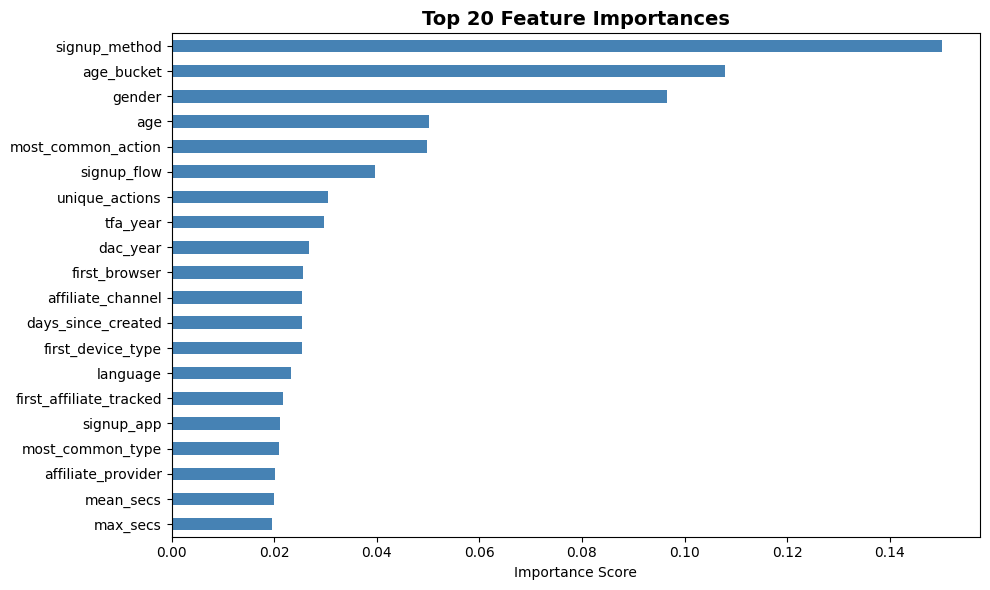

Saved: feature_importance.png


In [15]:
# Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print('Saved: feature_importance.png')


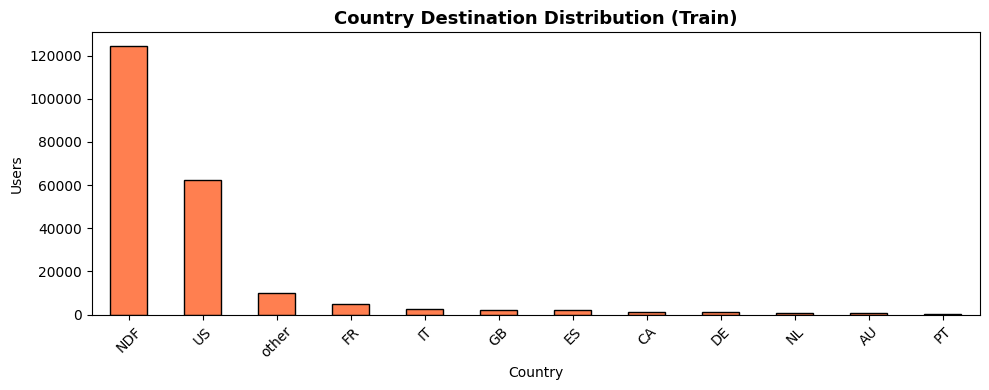

Saved: country_distribution.png


In [16]:
# Country Distribution
fig, ax = plt.subplots(figsize=(10, 4))
counts = pd.Series(le_target.inverse_transform(y)).value_counts()
counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Country Destination Distribution (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Users')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('country_distribution.png', dpi=120)
plt.show()
print('Saved: country_distribution.png')


## 11. Generate Top-5 Predictions for Test Set

In [17]:
test_proba   = model.predict_proba(X_test)
top5_indices = np.argsort(-test_proba, axis=1)[:, :5]

test_ids = test_df['id'].values
rows = []
for i, user_id in enumerate(test_ids):
    for idx in top5_indices[i]:
        rows.append({'id': user_id, 'country': le_target.classes_[idx]})

submission = pd.DataFrame(rows)
submission.to_csv('../data/processed/submission.csv', index=False)

print(f' ../data/processed/submission.csv saved!')
print(f'  Rows:  {len(submission)}')
print(f'  Users: {submission["id"].nunique()}')
print(f'\nTop predicted countries:')
print(submission['country'].value_counts())


 submission.csv saved!
  Rows:  310480
  Users: 62096

Top predicted countries:
country
US       62096
NDF      62083
other    61500
FR       53747
IT       24725
GB       18693
CA       14615
ES        9362
NL        1698
DE        1307
AU         480
PT         174
Name: count, dtype: int64


In [18]:
# Show top-5 for first 5 users
print('Top-5 predictions for first 5 test users:')
print('='*52)
for uid in test_ids[:5]:
    preds = submission[submission['id'] == uid]['country'].tolist()
    print(f'{uid}: {preds}')


Top-5 predictions for first 5 test users:
5uwns89zht: ['NDF', 'US', 'other', 'IT', 'GB']
jtl0dijy2j: ['NDF', 'US', 'other', 'FR', 'ES']
xx0ulgorjt: ['US', 'NDF', 'other', 'FR', 'CA']
6c6puo6ix0: ['US', 'NDF', 'other', 'FR', 'GB']
czqhjk3yfe: ['US', 'other', 'NDF', 'FR', 'CA']


In [19]:
# Save the model and label encoder
import pickle

with open('airbnb_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('label_encoder.pkl', 'wb') as f:
    # Save the target LabelEncoder
    pickle.dump(le_target, f)

print('Model and Label Encoder saved successfully as airbnb_model.pkl and label_encoder.pkl!')

Model and Label Encoder saved successfully as airbnb_model.pkl and label_encoder.pkl!


---
## Summary

| Step | Details |
|------|----------|
| **Data** | `train_users_2.csv` (213k users) + `sessions.csv` (10.5M rows, aggregated) |
| **Session Features** | count, total/mean/max secs, unique actions, unique devices, most common action/device/type |
| **User Features** | DAC date parts, timestamp parts, cleaned age, age bucket, encoded categoricals |
| **Model** | XGBoost `multi:softprob`, 300 trees, depth=6, lr=0.1 |
| **Metric** | NDCG@5 (Kaggle) + Top-1 accuracy on 20% hold-out |
| **Output** | `submission.csv` — 5 rows per test user (top-5 countries) |